In [150]:
%load_ext autoreload
%autoreload 2

import sys
import featuregraph as fg
from featuregraph.behaviors.transition import Transition

from featuregraph.operators.states import (
    rising_state
)

print("Python:", sys.executable)
print("FeatureGraph:", fg.__file__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Python: /usr/local/bin/python
FeatureGraph: /workspaces/featuregraph/src/featuregraph/__init__.py


In [151]:
# create a transition object

In [152]:
diff_lag = 10
eps = 0.01

bidmc = fg.datasets.bidmc(subject=35)

bidmc['respiration_smooth'] = bidmc['respiration'].rolling(50).mean()

bidmc_transition = Transition(
    bidmc,
    signal="respiration_smooth",
    direction='rising',
    op=rising_state,
    group="subject",
    diff_lag=diff_lag,
    eps=eps,
)

df = bidmc_transition.df
df['respiration_smooth'] = df['respiration'].rolling(100).max().rolling(100).mean().shift(-100)
df['respiration_rising'] = df['respiration_smooth'].diff() > 0
df['respiration_falling'] = df['respiration_smooth'].diff() < 0
df['exit_respiration_rising'] = df['respiration_rising'].astype(int).diff() == -1
# df['respiration_sustained_rise'] = df['respiration_rising'].astype(int).diff() == 1
# df['rate_of_change'] = df['respiration'].diff()
# df['max_rate_of_change'] = df.groupby('respiration_id').transform('max')['rate_of_change']
# df['mean_rate_of_change'] = df.groupby('respiration_id').transform('mean')['rate_of_change']

(<Figure size 1600x880 with 4 Axes>,
 array([<Axes: ylabel='respiration'>, <Axes: ylabel='respiration_smooth'>,
        <Axes: ylabel='respiration_rising'>,
        <Axes: xlabel='Time', ylabel='exit_respiration_rising'>],
       dtype=object))

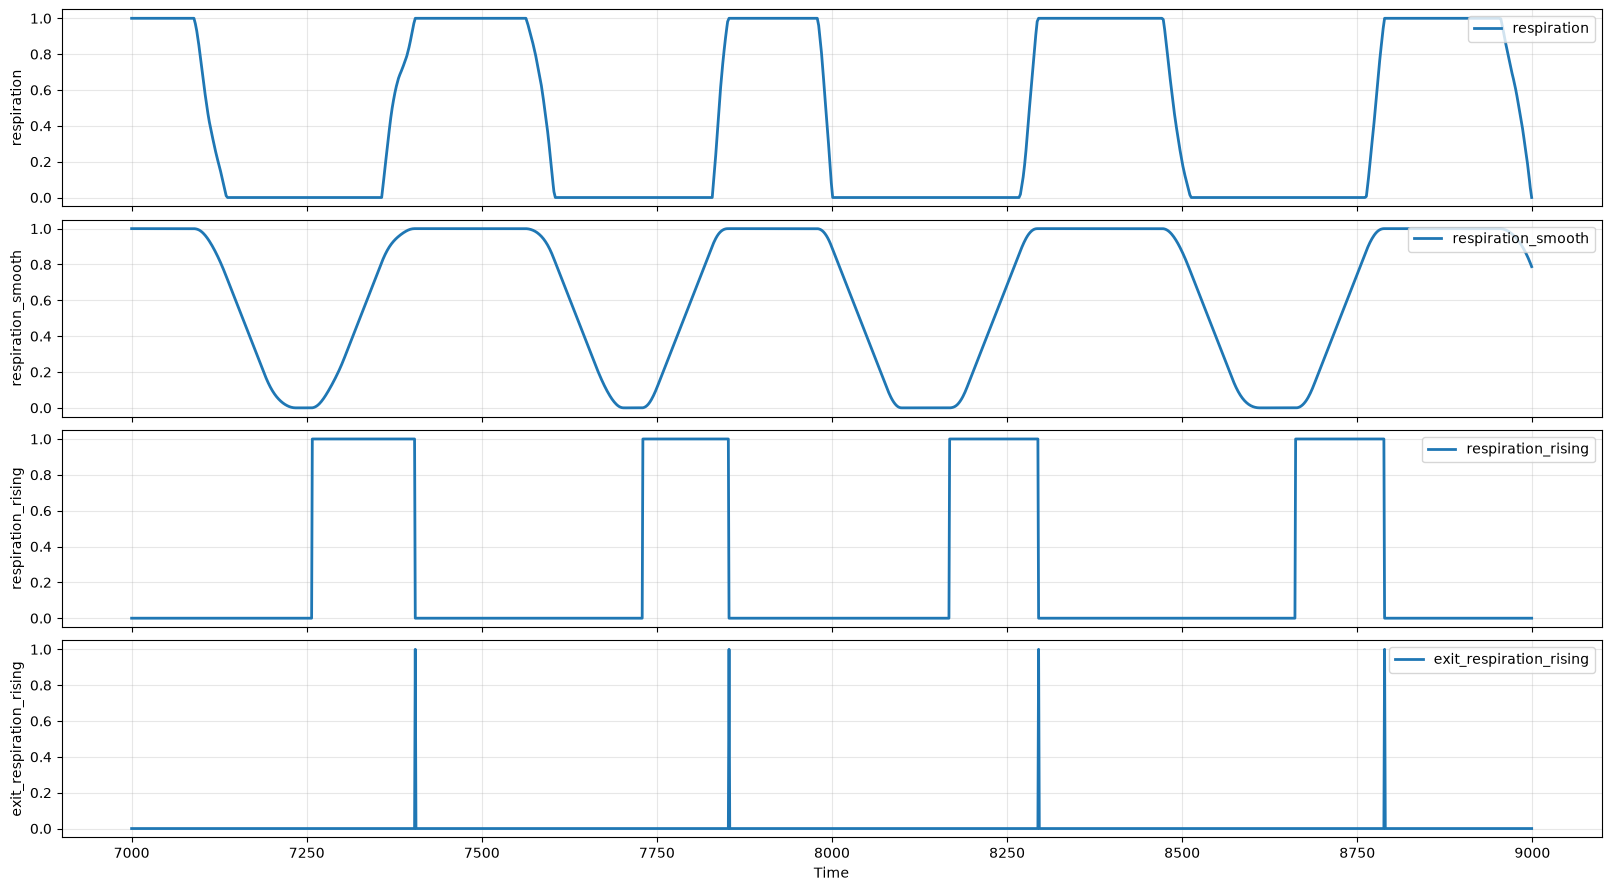

In [153]:
fg.plot(df[7000:9000], [['respiration'],
                              ['respiration_smooth'],
                            #   ['respiration_sustained_rise'],
                              ['respiration_rising'],
                              ['exit_respiration_rising'],
                            #   ['respiration_id'],
                            #   ['max_rate_of_change'],
                            #   ['mean_rate_of_change']
                             ]
)

In [154]:
summarydf = bidmc_transition.summary()

In [155]:
summarydf[50:80]

,duration,start_value,end_value,net_change,mean_rate
respiration_smooth_id,,,,,
50,67,0.930108,0.930391,0.000283,0.000004
51,65,0.939834,0.902845,-0.036989,-0.000569
52,69,0.912796,0.928563,0.015767,0.000229
53,65,0.938211,0.820078,-0.118133,-0.001817
54,81,0.829980,0.904702,0.074721,0.000922
55,69,0.914389,0.912053,-0.002336,-0.000034
56,69,0.921935,0.915308,-0.006627,-0.000096
57,69,0.924937,0.922844,-0.002092,-0.000030
58,67,0.932590,0.921046,-0.011544,-0.000172
